### STEP 1, doing installation

In [ ]:
# !pip install langchain langchain-openai langchain-chroma chromadb pypdf python-dotenv pandas jupyter
# !pip freeze > requirements.txt

In [1]:
# Cell 1: Import libraries and load environment variables
import os
from dotenv import load_dotenv
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma
import pandas as pd

# Load environment variables
load_dotenv()

# Verify OpenAI API key
api_key = os.getenv("OPENAI_API_KEY")
if not api_key:
    raise ValueError("OPENAI_API_KEY not found in .env file")

print("Environment setup successful. API key loaded.")
# Cell 2: Test OpenAI API connectivity
try:
    embeddings = OpenAIEmbeddings(model="text-embedding-ada-002")
    test_embedding = embeddings.embed_query("Test query")
    print(f"Embedding test successful. Sample embedding length: {len(test_embedding)}")
except Exception as e:
    print(f"Error connecting to OpenAI API: {e}")

Environment setup successful. API key loaded.
Embedding test successful. Sample embedding length: 1536


### Step 2: Explore and Prepare the Data Directory

In [4]:
# Cell 3: Explore and Prepare Data Directory
import os
import pandas as pd
from pypdf import PdfReader

# Define the data directory
DATA_DIR = "./data"

# Function to check if a PDF is readable
def is_pdf_readable(file_path):
    try:
        PdfReader(file_path)
        return True
    except Exception as e:
        print(f"Warning: Cannot read {file_path}: {e}")
        return False

# Walk through the data directory and collect metadata
def explore_data_directory(data_dir):
    documents = []
    for root, _, files in os.walk(data_dir):
        # Extract series from subfolder name (relative to data_dir)
        series = os.path.basename(root) if root != data_dir else None
        for file in files:
            if file.lower().endswith(".pdf"):
                file_path = os.path.join(root, file)
                # Check if PDF is readable
                if is_pdf_readable(file_path):
                    # Use file name (without .pdf) as category, or set to None
                    category = os.path.splitext(file)[0]
                    metadata = {
                        "file_path": file_path,
                        "series": series,
                        "category": category
                    }
                    documents.append(metadata)
                else:
                    print(f"Skipping {file_path} due to read error")

    return documents

# Run exploration
documents = explore_data_directory(DATA_DIR)

# Convert to DataFrame for easy inspection
df = pd.DataFrame(documents)

# Print summary
print(f"Total PDFs found: {len(documents)}")
print("\nSample of documents (first 5):")
print(df.head())

# Save DataFrame to CSV for reference
df.to_csv("document_metadata.csv", index=False)
print("\nMetadata saved to document_metadata.csv")

# Optional: Group by series to see distribution
print("\nDistribution by series:")
print(df.groupby("series").size())

Ignoring wrong pointing object 26 65536 (offset 0)
Ignoring wrong pointing object 27 65536 (offset 0)
Ignoring wrong pointing object 36 65536 (offset 0)
Ignoring wrong pointing object 48 65536 (offset 0)


Total PDFs found: 212

Sample of documents (first 5):
                                           file_path  \
0  ./data\Audits and Investigations\N_PD_9800_001...   
1  ./data\Audits and Investigations\N_PD_9910_001...   
2  ./data\Financial Management\N_PD_9010_002A__ma...   
3  ./data\Financial Management\N_PD_9050_001B__ma...   
4  ./data\Financial Management\N_PD_9050_003G__ma...   

                      series              category  
0  Audits and Investigations  N_PD_9800_001B__main  
1  Audits and Investigations  N_PD_9910_001B__main  
2       Financial Management  N_PD_9010_002A__main  
3       Financial Management  N_PD_9050_001B__main  
4       Financial Management  N_PD_9050_003G__main  

Metadata saved to document_metadata.csv

Distribution by series:
series
Audits and Investigations                                2
Financial Management                                    44
Human Resources and Personnel                           32
Legal Policies                           

### Step 3: Load Documents with Metadata

In [6]:
# Cell 4: Load Documents with Metadata (Fixed)
import logging
import sys
from contextlib import redirect_stderr
from io import StringIO
from langchain_community.document_loaders import PyPDFLoader
import pandas as pd
import pickle
import re

# Set up logging for PDF warnings
logging.basicConfig(filename="pdf_warnings.log", level=logging.WARNING,
                    format="%(asctime)s - %(levelname)s - %(message)s")
affected_files = []

# Custom stream to capture stderr warnings
class WarningCapture(StringIO):
    def write(self, s):
        super().write(s)
        if "Ignoring wrong pointing object" in s:
            logging.warning(s.strip())
            # Extract file path from previous log or context (approximate)
            if affected_files and "Loading" in s:
                affected_files.append(current_file_path)  # Set in loop below

# Load metadata from CSV
df = pd.read_csv("document_metadata.csv")

# Function to clean category
def clean_category(category):
    category = re.sub(r'__main$', '', category)
    category = category.rstrip('_')
    return category

# Function to load PDFs into LangChain Documents
def load_documents_with_metadata(metadata_df):
    documents = []
    global current_file_path  # To track file for warnings
    stderr_capture = WarningCapture()

    for _, row in metadata_df.iterrows():
        file_path = row["file_path"]
        current_file_path = file_path  # Update for warning capture
        series = row["series"]
        category = clean_category(row["category"])

        try:
            with redirect_stderr(stderr_capture):
                loader = PyPDFLoader(file_path)
                docs = loader.load()

            for doc in docs:
                doc.metadata.update({
                    "series": series,
                    "category": category,
                    "file_path": file_path
                })
                documents.append(doc)

            print(f"Loaded {file_path}: {len(docs)} pages")
        except Exception as e:
            error_msg = f"Error loading {file_path}: {e}"
            logging.error(error_msg)
            affected_files.append(file_path)
            print(error_msg)

    return documents

# Load documents (limit to first 10 PDFs for testing)
subset_df = df.head(10)
documents = load_documents_with_metadata(subset_df)

# Print sample documents
print(f"\nTotal documents (pages) loaded: {len(documents)}")
print("\nSample document (first page):")
if documents:
    sample_doc = documents[0]
    print(f"Content (first 200 chars): {sample_doc.page_content[:200]}...")
    print(f"Metadata: {sample_doc.metadata}")

# Save documents to pickle for reuse
with open("loaded_documents.pkl", "wb") as f:
    pickle.dump(documents, f)
print("\nDocuments saved to loaded_documents.pkl")

# Save affected PDFs to txt
with open("affected_pdfs.txt", "w") as f:
    for path in set(affected_files):  # Use set to avoid duplicates
        f.write(f"{path}\n")
print(f"\nAffected PDFs ({len(affected_files)}) saved to affected_pdfs.txt")
print("Check pdf_warnings.log for details.")

Loaded ./data\Audits and Investigations\N_PD_9800_001B__main.pdf: 5 pages
Loaded ./data\Audits and Investigations\N_PD_9910_001B__main.pdf: 5 pages
Loaded ./data\Financial Management\N_PD_9010_002A__main.pdf: 3 pages
Loaded ./data\Financial Management\N_PD_9050_001B__main.pdf: 3 pages
Loaded ./data\Financial Management\N_PD_9050_003G__main.pdf: 3 pages
Loaded ./data\Financial Management\N_PD_9050_006K__main.pdf: 7 pages
Loaded ./data\Financial Management\N_PD_9080_001H__main.pdf: 4 pages
Loaded ./data\Financial Management\N_PD_9250_001A__main.pdf: 4 pages
Loaded ./data\Financial Management\N_PD_9501_001I__main.pdf: 4 pages
Loaded ./data\Financial Management\N_PD_9645_002F__main.pdf: 5 pages

Total documents (pages) loaded: 43

Sample document (first page):
Content (first 200 chars): | NODIS Library | Audits and Investigations(9800s) | Search | 
 NASA
Policy
Directive 
NPD 9800.1B
Effective Date: June 09, 2009
Expiration Date: May 22, 2029
COMPLIANCE IS MANDATORY FOR NASA EMPLOYEE...
Me

### Step 4: Split Documents into Chunks

In [7]:
# Cell 5: Split Documents into Chunks
from langchain_text_splitters import RecursiveCharacterTextSplitter
import pickle
import statistics

# Load documents from pickle
with open("loaded_documents.pkl", "rb") as f:
    documents = pickle.load(f)

# Initialize text splitter
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,  # ~200-300 words
    chunk_overlap=200,  # To maintain context
    length_function=len,
    add_start_index=True  # Track start index in metadata
)

# Split documents
chunked_documents = text_splitter.split_documents(documents)

# Print stats
chunk_lengths = [len(doc.page_content) for doc in chunked_documents]
print(f"Total chunks created: {len(chunked_documents)}")
print(f"Average chunk length: {statistics.mean(chunk_lengths):.1f} chars")
print(f"Min chunk length: {min(chunk_lengths)} chars")
print(f"Max chunk length: {max(chunk_lengths)} chars")

# Print sample chunks
print("\nSample chunks (first 3):")
for i, doc in enumerate(chunked_documents[:3]):
    print(f"\nChunk {i+1}:")
    print(f"Content (first 200 chars): {doc.page_content[:200]}...")
    print(f"Metadata: {doc.metadata}")

# Save chunked documents to pickle for reuse
with open("chunked_documents.pkl", "wb") as f:
    pickle.dump(chunked_documents, f)
print("\nChunked documents saved to chunked_documents.pkl")

Total chunks created: 163
Average chunk length: 878.9 chars
Min chunk length: 265 chars
Max chunk length: 999 chars

Sample chunks (first 3):

Chunk 1:
Content (first 200 chars): | NODIS Library | Audits and Investigations(9800s) | Search | 
 NASA
Policy
Directive 
NPD 9800.1B
Effective Date: June 09, 2009
Expiration Date: May 22, 2029
COMPLIANCE IS MANDATORY FOR NASA EMPLOYEE...
Metadata: {'producer': 'iText 2.1.0 (by lowagie.com)', 'creator': 'PyPDF', 'creationdate': '2024-05-22T13:16:20-04:00', 'moddate': '2024-05-22T13:16:20-04:00', 'source': './data\\Audits and Investigations\\N_PD_9800_001B__main.pdf', 'total_pages': 5, 'page': 0, 'page_label': '1', 'series': 'Audits and Investigations', 'category': 'N_PD_9800_001B', 'file_path': './data\\Audits and Investigations\\N_PD_9800_001B__main.pdf', 'start_index': 0}

Chunk 2:
Content (first 200 chars): responsibilities. 
1. POLICY 
It is NASA policy to abide by the requirements established for the Agency under the Inspector General Act 

### Step 5: Generate Embeddings

In [8]:
!pip install retry


   ---------------------------------------- 0/2 [py]
   ---------------------------------------- 2/2 [retry]



In [9]:
!pip freeze > requirements.txt

In [10]:
# Cell 6: Generate Embeddings
from langchain_openai import OpenAIEmbeddings
import pickle
import time
from retry import retry  # Requires `pip install retry`
import logging

# Set up logging for embedding errors
logging.basicConfig(filename="embedding_errors.log", level=logging.ERROR,
                    format="%(asctime)s - %(levelname)s - %(message)s")

# Load chunked documents
with open("chunked_documents.pkl", "rb") as f:
    chunked_documents = pickle.load(f)

# Initialize OpenAI embeddings
embeddings_model = OpenAIEmbeddings(
    model="text-embedding-ada-002",
    openai_api_key=os.getenv("OPENAI_API_KEY")
)

# Function to estimate token count (approximate, for cost estimation)
def estimate_tokens(text):
    return len(text) // 4  # Rough estimate: 1 token ≈ 4 chars

# Generate embeddings with batching and error handling
@retry(tries=3, delay=2, backoff=2)  # Retry 3 times with exponential backoff
def generate_embeddings(documents):
    try:
        # Extract text from documents
        texts = [doc.page_content for doc in documents]
        # Estimate total tokens for cost
        total_tokens = sum(estimate_tokens(text) for text in texts)
        # Generate embeddings
        start_time = time.time()
        embeddings = embeddings_model.embed_documents(texts)
        end_time = time.time()
        return embeddings, total_tokens, end_time - start_time
    except Exception as e:
        logging.error(f"Embedding error: {e}")
        raise

# Generate embeddings for chunks
try:
    embedding_vectors, total_tokens, time_taken = generate_embeddings(chunked_documents)
    print(f"Generated embeddings for {len(embedding_vectors)} chunks")
    print(f"Total estimated tokens: {total_tokens}")
    print(f"Time taken: {time_taken:.2f} seconds")

    # Sample embedding
    if embedding_vectors:
        print(f"\nSample embedding (first 10 values, chunk 1):")
        print(embedding_vectors[0][:10])
        print(f"Embedding length: {len(embedding_vectors[0])}")

    # Estimate cost (based on $0.0001 per 1K tokens for ada-002, as of 2023)
    cost_per_1k_tokens = 0.0001
    estimated_cost = (total_tokens / 1000) * cost_per_1k_tokens
    print(f"Estimated embedding cost: ${estimated_cost:.4f}")

    # Save embeddings with documents for next step
    with open("embeddings.pkl", "wb") as f:
        pickle.dump({"documents": chunked_documents, "embeddings": embedding_vectors}, f)
    print("\nEmbeddings and documents saved to embeddings.pkl")

except Exception as e:
    print(f"Failed to generate embeddings: {e}")
    print("Check embedding_errors.log for details.")


Generated embeddings for 163 chunks
Total estimated tokens: 35757
Time taken: 3.35 seconds

Sample embedding (first 10 values, chunk 1):
[-0.004153097979724407, -0.021631572395563126, -0.02962406910955906, -0.017826270312070847, -0.010290681384503841, -0.0003149773692712188, -0.0010288977064192295, -0.004579319152981043, -0.020213108509778976, -0.0026715537533164024]
Embedding length: 1536
Estimated embedding cost: $0.0036

Embeddings and documents saved to embeddings.pkl


### Step 6: Set Up and Populate the Vector Database

In [3]:
# Cell 7: Set Up and Populate the Vector Database (Fixed)
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings
import pickle
import os
import logging
import shutil
import uuid

# Set up logging for vector store errors
logging.basicConfig(filename="vectorstore_errors.log", level=logging.ERROR,
                    format="%(asctime)s - %(levelname)s - %(message)s")

# Load embeddings and documents from pickle
with open("embeddings.pkl", "rb") as f:
    data = pickle.load(f)
chunked_documents = data["documents"]
embedding_vectors = data["embeddings"]

# Add unique IDs to documents to prevent duplicates
for i, doc in enumerate(chunked_documents):
    doc.metadata["id"] = f"doc_{i}_{uuid.uuid4().hex[:8]}"  # Unique ID per document

# Initialize OpenAI embeddings (for query embedding in test)
embeddings_model = OpenAIEmbeddings(model="text-embedding-ada-002")

# Set persistence path
PERSISTENT_DIR = "./chroma_db"
os.makedirs(PERSISTENT_DIR, exist_ok=True)

try:
    # Clear existing collection to avoid duplicates (optional: comment out if you want to keep existing data)
    if os.path.exists(PERSISTENT_DIR):
        shutil.rmtree(PERSISTENT_DIR)
        print(f"Cleared existing directory {PERSISTENT_DIR}")
    os.makedirs(PERSISTENT_DIR, exist_ok=True)

    # Create Chroma vector store
    vectorstore = Chroma.from_documents(
        documents=chunked_documents,
        embedding=embeddings_model,
        persist_directory=PERSISTENT_DIR,
        collection_name="nasa_policies"
    )

    # Print confirmation
    print(f"Vector store created in {PERSISTENT_DIR}")
    print(f"Added {len(chunked_documents)} documents to collection '{vectorstore._collection.name}'")

    # Verify directory contents
    dir_contents = os.listdir(PERSISTENT_DIR)
    print(f"Contents of {PERSISTENT_DIR}: {dir_contents}")

    # Test retrieval: Create a retriever and query
    retriever = vectorstore.as_retriever(search_kwargs={"k": 3})
    sample_query = "NASA policy on audits and investigations"
    relevant_docs = retriever.invoke(sample_query)

    print(f"\nSample retrieval for query: '{sample_query}'")
    for i, doc in enumerate(relevant_docs):
        print(f"\nTop result {i+1}:")
        print(f"Content (first 100 chars): {doc.page_content[:100]}...")
        print(f"Metadata: {doc.metadata}")

    # Confirm collection size
    collection_size = vectorstore._collection.count()
    print(f"\nCollection size: {collection_size} documents")

    if collection_size != len(chunked_documents):
        logging.warning(f"Mismatch: Expected {len(chunked_documents)} documents, got {collection_size}")
        print(f"Warning: Collection size ({collection_size}) does not match expected ({len(chunked_documents)})")

except Exception as e:
    logging.error(f"Vector store error: {e}")
    print(f"Failed to process vector store: {e}")
    print("Check vectorstore_errors.log for details.")

Cleared existing directory ./chroma_db
Vector store created in ./chroma_db
Added 163 documents to collection 'nasa_policies'
Contents of ./chroma_db: ['59d68496-c4e8-448f-bab4-6ea36fc890d1', 'chroma.sqlite3']

Sample retrieval for query: 'NASA policy on audits and investigations'

Top result 1:
Content (first 100 chars): Audit Agency, other executive branch audit organizations, and non-Federal auditors; policy is found ...
Metadata: {'creator': 'PyPDF', 'page': 1, 'category': 'N_PD_9910_001B', 'file_path': './data\\Audits and Investigations\\N_PD_9910_001B__main.pdf', 'id': 'doc_28_24d5aabd', 'creationdate': '2024-11-04T11:03:37-05:00', 'page_label': '2', 'producer': 'iText 2.1.0 (by lowagie.com)', 'series': 'Audits and Investigations', 'moddate': '2024-11-04T11:03:37-05:00', 'start_index': 868, 'total_pages': 5, 'source': './data\\Audits and Investigations\\N_PD_9910_001B__main.pdf'}

Top result 2:
Content (first 100 chars): | NODIS Library | Audits and Investigations(9800s) | Search 

### Step 6 : more Testing


In [4]:
# Cell 8: Test Retrieval with Financial Policy Query
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings
import logging

# Set up logging for vector store errors
logging.basicConfig(filename="vectorstore_errors.log", level=logging.ERROR,
                    format="%(asctime)s - %(levelname)s - %(message)s")

# Initialize OpenAI embeddings (for query embedding)
embeddings_model = OpenAIEmbeddings(model="text-embedding-ada-002")

# Load existing Chroma vector store
PERSISTENT_DIR = "./chroma_db"
try:
    vectorstore = Chroma(
        collection_name="nasa_policies",
        embedding_function=embeddings_model,
        persist_directory=PERSISTENT_DIR
    )

    # Confirm collection size
    collection_size = vectorstore._collection.count()
    print(f"Loaded vector store from {PERSISTENT_DIR}")
    print(f"Collection '{vectorstore._collection.name}' size: {collection_size} documents")

    # Test retrieval with new query
    retriever = vectorstore.as_retriever(search_kwargs={"k": 3})
    sample_query = "NASA financial policy"
    relevant_docs = retriever.invoke(sample_query)

    print(f"\nSample retrieval for query: '{sample_query}'")
    for i, doc in enumerate(relevant_docs):
        print(f"\nTop result {i+1}:")
        print(f"Content (first 100 chars): {doc.page_content[:100]}...")
        print(f"Metadata: {doc.metadata}")

except Exception as e:
    logging.error(f"Vector store error: {e}")
    print(f"Failed to load or query vector store: {e}")
    print("Check vectorstore_errors.log for details.")

Loaded vector store from ./chroma_db
Collection 'nasa_policies' size: 163 documents

Sample retrieval for query: 'NASA financial policy'

Top result 1:
Content (first 100 chars): | NODIS Library | Financial Management(9000s) | Search | 
 NASA
Policy
Directive 
NPD 9080.1H
Effect...
Metadata: {'total_pages': 4, 'source': './data\\Financial Management\\N_PD_9080_001H__main.pdf', 'start_index': 0, 'file_path': './data\\Financial Management\\N_PD_9080_001H__main.pdf', 'creator': 'PyPDF', 'creationdate': '2025-07-16T14:13:47-04:00', 'page': 0, 'series': 'Financial Management', 'id': 'doc_102_d12147f9', 'category': 'N_PD_9080_001H', 'moddate': '2025-07-16T14:13:47-04:00', 'page_label': '1', 'producer': 'iText 2.1.0 (by lowagie.com)'}

Top result 2:
Content (first 100 chars): | NODIS Library | Financial Management(9000s) | Search | 
 NASA
Policy
Directive 
NPD 9010.2A
Effect...
Metadata: {'page': 0, 'start_index': 0, 'creationdate': '2023-01-23T10:08:25-05:00', 'page_label': '1', 'id': 'doc_4

### Step 6 : more Testing

In [5]:
# Cell 9: Test Retrieval with Budgeting Procedures Query
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings
import logging

# Set up logging for vector store errors
logging.basicConfig(filename="vectorstore_errors.log", level=logging.ERROR,
                    format="%(asctime)s - %(levelname)s - %(message)s")

# Initialize OpenAI embeddings (for query embedding)
embeddings_model = OpenAIEmbeddings(model="text-embedding-ada-002")

# Load existing Chroma vector store
PERSISTENT_DIR = "./chroma_db"
try:
    vectorstore = Chroma(
        collection_name="nasa_policies",
        embedding_function=embeddings_model,
        persist_directory=PERSISTENT_DIR
    )

    # Confirm collection size
    collection_size = vectorstore._collection.count()
    print(f"Loaded vector store from {PERSISTENT_DIR}")
    print(f"Collection '{vectorstore._collection.name}' size: {collection_size} documents")

    # Test retrieval with new query
    retriever = vectorstore.as_retriever(search_kwargs={"k": 3})
    sample_query = "NASA budgeting procedures"
    relevant_docs = retriever.invoke(sample_query)

    print(f"\nSample retrieval for query: '{sample_query}'")
    for i, doc in enumerate(relevant_docs):
        print(f"\nTop result {i+1}:")
        print(f"Content (first 100 chars): {doc.page_content[:100]}...")
        print(f"Metadata: {doc.metadata}")

except Exception as e:
    logging.error(f"Vector store error: {e}")
    print(f"Failed to load or query vector store: {e}")
    print("Check vectorstore_errors.log for details.")

Loaded vector store from ./chroma_db
Collection 'nasa_policies' size: 163 documents

Sample retrieval for query: 'NASA budgeting procedures'

Top result 1:
Content (first 100 chars): 31 United States Code (U.S.C.) §§ 1341-1342, 1349-1351, 1511-1519.
b. It is NASA's policy to maintai...
Metadata: {'file_path': './data\\Financial Management\\N_PD_9050_003G__main.pdf', 'category': 'N_PD_9050_003G', 'creationdate': '2024-08-23T17:24:36-04:00', 'page_label': '1', 'moddate': '2024-08-23T17:24:36-04:00', 'source': './data\\Financial Management\\N_PD_9050_003G__main.pdf', 'creator': 'PyPDF', 'total_pages': 3, 'series': 'Financial Management', 'producer': 'iText 2.1.0 (by lowagie.com)', 'start_index': 716, 'id': 'doc_60_1192423c', 'page': 0}

Top result 2:
Content (first 100 chars): (1) The full-cost or market-price of Federal Government service from which a special benefit is deri...
Metadata: {'creator': 'PyPDF', 'series': 'Financial Management', 'page': 1, 'page_label': '2', 'creationdate': 

### Step 7: Implement Basic Retrieval

In [6]:
# Cell 10: Implement Basic Retrieval
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings
import logging
import os

# Set up logging for retrieval errors
logging.basicConfig(filename="retrieval_errors.log", level=logging.ERROR,
                    format="%(asctime)s - %(levelname)s - %(message)s")

# Initialize OpenAI embeddings (for query embedding)
embeddings_model = OpenAIEmbeddings(model="text-embedding-ada-002")

# Load existing Chroma vector store
PERSISTENT_DIR = "./chroma_db"
try:
    vectorstore = Chroma(
        collection_name="nasa_policies",
        embedding_function=embeddings_model,
        persist_directory=PERSISTENT_DIR
    )

    # Confirm collection size
    collection_size = vectorstore._collection.count()
    print(f"Loaded vector store from {PERSISTENT_DIR}")
    print(f"Collection '{vectorstore._collection.name}' size: {collection_size} documents")

    # Create retriever
    retriever = vectorstore.as_retriever(search_kwargs={"k": 3})

    # Test queries
    test_queries = [
        "NASA contract audits",  # Specific, Audits and Investigations
        "NASA financial reporting",  # Specific, Financial Management
        "NASA policy overview"  # Broad, both series
    ]

    for query in test_queries:
        print(f"\nSample retrieval for query: '{query}'")
        try:
            relevant_docs = retriever.invoke(query)
            for i, doc in enumerate(relevant_docs):
                print(f"\nTop result {i+1}:")
                print(f"Content (first 100 chars): {doc.page_content[:100]}...")
                print(f"Metadata: {doc.metadata}")
        except Exception as e:
            logging.error(f"Retrieval error for query '{query}': {e}")
            print(f"Failed to retrieve for query '{query}': {e}")

    # Test metadata filtering (example: Financial Management series)
    print("\nTesting metadata filtering: series='Financial Management'")
    try:
        filtered_retriever = vectorstore.as_retriever(
            search_kwargs={
                "k": 3,
                "filter": {"series": "Financial Management"}
            }
        )
        query = "NASA budgeting procedures"
        relevant_docs = filtered_retriever.invoke(query)
        print(f"\nFiltered retrieval for query: '{query}' (series: Financial Management)")
        for i, doc in enumerate(relevant_docs):
            print(f"\nTop result {i+1}:")
            print(f"Content (first 100 chars): {doc.page_content[:100]}...")
            print(f"Metadata: {doc.metadata}")
    except Exception as e:
        logging.error(f"Filtered retrieval error: {e}")
        print(f"Failed to retrieve with filter: {e}")

except Exception as e:
    logging.error(f"Vector store error: {e}")
    print(f"Failed to load vector store: {e}")
    print("Check retrieval_errors.log for details.")

Loaded vector store from ./chroma_db
Collection 'nasa_policies' size: 163 documents

Sample retrieval for query: 'NASA contract audits'

Top result 1:
Content (first 100 chars): (6) Maintaining accurate records of the status of contract audit reports or recommendations through ...
Metadata: {'source': './data\\Audits and Investigations\\N_PD_9910_001B__main.pdf', 'moddate': '2024-11-04T11:03:37-05:00', 'page_label': '4', 'category': 'N_PD_9910_001B', 'producer': 'iText 2.1.0 (by lowagie.com)', 'creationdate': '2024-11-04T11:03:37-05:00', 'creator': 'PyPDF', 'page': 3, 'series': 'Audits and Investigations', 'start_index': 824, 'file_path': './data\\Audits and Investigations\\N_PD_9910_001B__main.pdf', 'total_pages': 5, 'id': 'doc_39_65aa9d86'}

Top result 2:
Content (first 100 chars): Audit Agency, other executive branch audit organizations, and non-Federal auditors; policy is found ...
Metadata: {'creator': 'PyPDF', 'producer': 'iText 2.1.0 (by lowagie.com)', 'moddate': '2024-11-04T11:

###  Step 8: Generate Answers Using Retrieved Context

In [7]:
# Cell 11: Generate Answers Using Retrieved Context
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_core.prompts import PromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser
import logging
import os

# Set up logging for RAG errors
logging.basicConfig(filename="rag_errors.log", level=logging.ERROR,
                    format="%(asctime)s - %(levelname)s - %(message)s")

# Initialize OpenAI embeddings and LLM
embeddings_model = OpenAIEmbeddings(model="text-embedding-ada-002")
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

# Load existing Chroma vector store
PERSISTENT_DIR = "./chroma_db"
try:
    vectorstore = Chroma(
        collection_name="nasa_policies",
        embedding_function=embeddings_model,
        persist_directory=PERSISTENT_DIR
    )

    # Confirm collection size
    collection_size = vectorstore._collection.count()
    print(f"Loaded vector store from {PERSISTENT_DIR}")
    print(f"Collection '{vectorstore._collection.name}' size: {collection_size} documents")

    # Create retriever
    retriever = vectorstore.as_retriever(search_kwargs={"k": 3})

    # Define prompt template
    prompt_template = PromptTemplate.from_template(
        """You are a knowledgeable assistant for NASA policy queries. Use the following context to answer the query concisely and accurately. Cite the source PDF and page number for each piece of information used. If the context is insufficient, say so and provide a general answer based on available information.

        Context:
        {context}

        Query: {query}

        Answer:
        """
    )

    # Format context with citations
    def format_context(docs):
        return "\n\n".join(
            f"Source: {doc.metadata['category']} (Page {doc.metadata['page_label']}):\n{doc.page_content}"
            for doc in docs
        )

    # Create RAG chain
    rag_chain = (
        {"context": retriever | format_context, "query": RunnablePassthrough()}
        | prompt_template
        | llm
        | StrOutputParser()
    )

    # Test queries
    test_queries = [
        "What are NASA's procedures for contract audits?",
        "How does NASA handle financial reporting?",
        "Provide an overview of NASA's policy framework."
    ]

    for query in test_queries:
        print(f"\nProcessing query: '{query}'")
        try:
            answer = rag_chain.invoke(query)
            print(f"\nAnswer:\n{answer}")
        except Exception as e:
            logging.error(f"RAG error for query '{query}': {e}")
            print(f"Failed to process query '{query}': {e}")

    # Test filtered query (Financial Management)
    print("\nTesting filtered query: 'NASA budgeting procedures' (series: Financial Management)")
    try:
        filtered_retriever = vectorstore.as_retriever(
            search_kwargs={"k": 3, "filter": {"series": "Financial Management"}}
        )
        filtered_rag_chain = (
            {"context": filtered_retriever | format_context, "query": RunnablePassthrough()}
            | prompt_template
            | llm
            | StrOutputParser()
        )
        query = "What are NASA's budgeting procedures?"
        answer = filtered_rag_chain.invoke(query)
        print(f"\nAnswer:\n{answer}")
    except Exception as e:
        logging.error(f"Filtered RAG error: {e}")
        print(f"Failed to process filtered query: {e}")

except Exception as e:
    logging.error(f"Vector store error: {e}")
    print(f"Failed to load vector store: {e}")
    print("Check rag_errors.log for details.")

Loaded vector store from ./chroma_db
Collection 'nasa_policies' size: 163 documents

Processing query: 'What are NASA's procedures for contract audits?'

Answer:
NASA's procedures for contract audits are outlined in N_PD_9910_001B. Key elements include:

1. **Maintaining Records**: NASA is responsible for maintaining accurate records of the status of contract audit reports and recommendations throughout the resolution and corrective action process (Page 4).

2. **Documentation of Differences**: There must be full documentation of any significant differences between audit recommendations and final actions, including the rationale for any deviations (Page 4).

3. **Continuous Dialogue**: Establishing and maintaining continuous dialogue between contracting, audit, and audit follow-up personnel is essential for an effective process (Page 4).

4. **Reporting Concerns**: NASA employees must report any concerns regarding fraud, waste, abuse, or mismanagement to the Office of the Inspector Gen

### Step 9 Advancing the pipeline BY Adding Filtering and Ranking

In [3]:
# Cell 12: Add Filtering and Ranking
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_core.prompts import PromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser
import logging
import os
from datetime import datetime

# Set up logging for RAG errors
logging.basicConfig(filename="rag_errors.log", level=logging.ERROR,
                    format="%(asctime)s - %(levelname)s - %(message)s")

# Initialize OpenAI embeddings and LLM
embeddings_model = OpenAIEmbeddings(model="text-embedding-ada-002")
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

# Load existing Chroma vector store
PERSISTENT_DIR = "./chroma_db"
try:
    vectorstore = Chroma(
        collection_name="nasa_policies",
        embedding_function=embeddings_model,
        persist_directory=PERSISTENT_DIR
    )

    # Confirm collection size
    collection_size = vectorstore._collection.count()
    print(f"Loaded vector store from {PERSISTENT_DIR}")
    print(f"Collection '{vectorstore._collection.name}' size: {collection_size} documents")

    # Define prompt template
    prompt_template = PromptTemplate.from_template(
        """You are a knowledgeable assistant for NASA policy queries. Use the following context to answer the query concisely and accurately. Cite the source PDF and page number for each piece of information used. If the context is insufficient, say so and provide a general answer based on available information.

        Context:
        {context}

        Query: {query}

        Answer:
        """
    )

    # Format context with citations and similarity scores
    def format_context(docs):
        return "\n\n".join(
            f"Source: {doc.metadata['category']} (Page {doc.metadata['page_label']}, Similarity Score: {doc.metadata.get('score', 'N/A')}):\n{doc.page_content}"
            for doc in docs
        )

    # Ranking function: Sort by similarity score (default) and optionally by recency
    def rank_documents(docs, sort_by="score", reverse=True):
        for i, doc in enumerate(docs):
            # Simulate similarity score if not provided (Chroma doesn't return scores directly)
            doc.metadata['score'] = 1.0 - (i * 0.1)  # Mock score: 1.0, 0.9, 0.8, etc.
        if sort_by == "recency":
            docs.sort(key=lambda doc: datetime.strptime(doc.metadata['creationdate'], '%Y-%m-%dT%H:%M:%S%z'), reverse=True)
        return docs

    # Create RAG chain
    def create_rag_chain(retriever):
        return (
            {"context": retriever | rank_documents | format_context, "query": RunnablePassthrough()}
            | prompt_template
            | llm
            | StrOutputParser()
        )

    # Test queries with different filters and ranking
    test_cases = [
        {
            "query": "What are NASA's procedures for contract audits?",
            "filter": {"series": "Audits and Investigations"},
            "ranking": "score",
            "description": "Filter by Audits and Investigations, rank by similarity"
        },
        {
            "query": "How does NASA handle financial reporting?",
            "filter": {"category": "N_PD_9501_001I"},
            "ranking": "score",
            "description": "Filter by specific PDF (N_PD_9501_001I), rank by similarity"
        },
        {
            "query": "What are NASA's budgeting procedures?",
            "filter": {"series": "Financial Management", "creationdate": {"$gte": "2024-01-01T00:00:00-05:00"}},
            "ranking": "recency",
            "description": "Filter by Financial Management and post-2024 documents, rank by recency"
        }
    ]

    for case in test_cases:
        print(f"\nProcessing query: '{case['query']}' ({case['description']})")
        try:
            retriever = vectorstore.as_retriever(
                search_kwargs={"k": 3, "filter": case["filter"]}
            )
            rag_chain = create_rag_chain(retriever)
            answer = rag_chain.invoke(case["query"])
            print(f"\nAnswer:\n{answer}")
        except Exception as e:
            logging.error(f"RAG error for query '{case['query']}': {e}")
            print(f"Failed to process query '{case['query']}': {e}")

except Exception as e:
    logging.error(f"Vector store error: {e}")
    print(f"Failed to load vector store: {e}")
    print("Check rag_errors.log for details.")

Loaded vector store from ./chroma_db
Collection 'nasa_policies' size: 163 documents

Processing query: 'What are NASA's procedures for contract audits?' (Filter by Audits and Investigations, rank by similarity)

Answer:
NASA's procedures for contract audits include several key responsibilities and actions as outlined in the NASA Policy Directive (NPD) 9910.001B. 

1. **Record Maintenance**: NASA is responsible for maintaining accurate records of the status of contract audit reports or recommendations throughout the resolution and corrective action process (N_PD_9910_001B, Page 4).

2. **Documentation of Differences**: There must be full documentation of any significant differences between the audit recommendations and the final actions taken, including the rationale for any deviations (N_PD_9910_001B, Page 4).

3. **Continuous Dialogue**: Establishing and maintaining continuous dialogue between contracting, audit, and audit follow-up personnel is essential to achieve an effective audit

In [5]:
# # Cell 13: Re-run Query 3 with Fixed Filter
# from langchain_chroma import Chroma
# from langchain_openai import OpenAIEmbeddings, ChatOpenAI
# from langchain_core.prompts import PromptTemplate
# from langchain_core.runnables import RunnablePassthrough
# from langchain_core.output_parsers import StrOutputParser
# import logging
# from datetime import datetime
#
# # Set up logging
# logging.basicConfig(filename="rag_errors.log", level=logging.ERROR,
#                     format="%(asctime)s - %(levelname)s - %(message)s")
#
# # Initialize embeddings and LLM
# embeddings_model = OpenAIEmbeddings(model="text-embedding-ada-002")
# llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
#
# # Load vector store
# PERSISTENT_DIR = "./chroma_db"
# try:
#     vectorstore = Chroma(
#         collection_name="nasa_policies",
#         embedding_function=embeddings_model,
#         persist_directory=PERSISTENT_DIR
#     )
#     print(f"Loaded vector store from {PERSISTENT_DIR}")
#     print(f"Collection '{vectorstore._collection.name}' size: {vectorstore._collection.count()} documents")
#
#     # Prompt template
#     prompt_template = PromptTemplate.from_template(
#         """You are a knowledgeable assistant for NASA policy queries. Use the following context to answer the query concisely and accurately. Cite the source PDF and page number for each piece of information used. If the context is insufficient, say so and provide a general answer based on available information.
#
#         Context:
#         {context}
#
#         Query: {query}
#
#         Answer:
#         """
#     )
#
#     # Format context with citations and scores
#     def format_context(docs):
#         return "\n\n".join(
#             f"Source: {doc.metadata['category']} (Page {doc.metadata['page_label']}, Similarity Score: {doc.metadata.get('score', 'N/A')}):\n{doc.page_content}"
#             for doc in docs
#         )
#
#     # Ranking function
#     def rank_documents(docs, sort_by="score", reverse=True):
#         for i, doc in enumerate(docs):
#             doc.metadata['score'] = 1.0 - (i * 0.1)
#         if sort_by == "recency":
#             docs.sort(key=lambda doc: datetime.strptime(doc.metadata['creationdate'], '%Y-%m-%dT%H:%M:%S%z'), reverse=True)
#         return docs
#
#     # Create RAG chain
#     def create_rag_chain(retriever):
#         return (
#             {"context": retriever | rank_documents | format_context, "query": RunnablePassthrough()}
#             | prompt_template
#             | llm
#             | StrOutputParser()
#         )
#
#     # Test fixed query
#     query = "What are NASA's budgeting procedures?"
#     filter_config = {
#         "$and": [
#             {"series": "Financial Management"},
#             {"creationdate": {"$gte": "2024-01-01T00:00:00-05:00"}}
#         ]
#     }
#     print(f"\nProcessing query: '{query}' (Filter by Financial Management and post-2024 documents, rank by recency)")
#     try:
#         retriever = vectorstore.as_retriever(
#             search_kwargs={"k": 3, "filter": filter_config}
#         )
#         rag_chain = create_rag_chain(retriever)
#         answer = rag_chain.invoke(query)
#         print(f"\nAnswer:\n{answer}")
#     except Exception as e:
#         logging.error(f"RAG error for query '{query}': {e}")
#         print(f"Failed to process query '{query}': {e}")
#
# except Exception as e:
#     logging.error(f"Vector store error: {e}")
#     print(f"Failed to load vector store: {e}")
#     print("Check rag_errors.log for details.")

Loaded vector store from ./chroma_db
Collection 'nasa_policies' size: 163 documents

Processing query: 'What are NASA's budgeting procedures?' (Filter by Financial Management and post-2024 documents, rank by recency)
Failed to process query 'What are NASA's budgeting procedures?': Expected operand value to be an int or a float for operator $gte, got 2024-01-01T00:00:00-05:00 in query.


### Testing

In [6]:
# Cell 14: Re-run Query 3 with Simplified Filter
#enhance pipeline
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_core.prompts import PromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser
import logging
from datetime import datetime

# Set up logging
logging.basicConfig(filename="rag_errors.log", level=logging.ERROR,
                    format="%(asctime)s - %(levelname)s - %(message)s")

# Initialize embeddings and LLM
embeddings_model = OpenAIEmbeddings(model="text-embedding-ada-002")
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

# Load vector store
PERSISTENT_DIR = "./chroma_db"
try:
    vectorstore = Chroma(
        collection_name="nasa_policies",
        embedding_function=embeddings_model,
        persist_directory=PERSISTENT_DIR
    )
    print(f"Loaded vector store from {PERSISTENT_DIR}")
    print(f"Collection '{vectorstore._collection.name}' size: {vectorstore._collection.count()} documents")

    # Prompt template
    prompt_template = PromptTemplate.from_template(
        """You are a knowledgeable assistant for NASA policy queries. Use the following context to answer the query concisely and accurately. Cite the source PDF and page number for each piece of information used. If the context is insufficient, say so and provide a general answer based on available information.

        Context:
        {context}

        Query: {query}

        Answer:
        """
    )

    # Format context with citations and scores
    def format_context(docs):
        return "\n\n".join(
            f"Source: {doc.metadata['category']} (Page {doc.metadata['page_label']}, Similarity Score: {doc.metadata.get('score', 'N/A')}):\n{doc.page_content}"
            for doc in docs
        )

    # Ranking function
    def rank_documents(docs, sort_by="score", reverse=True):
        for i, doc in enumerate(docs):
            doc.metadata['score'] = 1.0 - (i * 0.1)
        if sort_by == "recency":
            docs.sort(key=lambda doc: datetime.strptime(doc.metadata['creationdate'], '%Y-%m-%dT%H:%M:%S%z'), reverse=True)
        return docs

    # Create RAG chain
    def create_rag_chain(retriever):
        return (
            {"context": retriever | rank_documents | format_context, "query": RunnablePassthrough()}
            | prompt_template
            | llm
            | StrOutputParser()
        )

    # Test fixed query
    query = "What are NASA's budgeting procedures?"
    filter_config = {"series": "Financial Management"}
    print(f"\nProcessing query: '{query}' (Filter by Financial Management, rank by recency)")
    try:
        retriever = vectorstore.as_retriever(
            search_kwargs={"k": 3, "filter": filter_config}
        )
        rag_chain = create_rag_chain(retriever)
        answer = rag_chain.invoke(query)
        print(f"\nAnswer:\n{answer}")
    except Exception as e:
        logging.error(f"RAG error for query '{query}': {e}")
        print(f"Failed to process query '{query}': {e}")

except Exception as e:
    logging.error(f"Vector store error: {e}")
    print(f"Failed to load vector store: {e}")
    print("Check rag_errors.log for details.")

Loaded vector store from ./chroma_db
Collection 'nasa_policies' size: 163 documents

Processing query: 'What are NASA's budgeting procedures?' (Filter by Financial Management, rank by recency)

Answer:
NASA's budgeting procedures are designed to ensure compliance with legal and regulatory requirements while maintaining effective financial management. Key aspects include:

1. **Positive Administrative Control of Funds**: NASA maintains a system to restrict obligations and expenditures to the lower of the amount apportioned or available in each appropriation or fund account, in accordance with NASA Procedural Requirements (NPR) 9470.1, Budget Execution (N_PD_9050_003G, Page 1).

2. **Responsibility for Violations**: The policy identifies individuals responsible for any violations of the Antideficiency Act (ADA) or other administrative divisions of funds, as outlined in NPR 9050.3 (N_PD_9050_003G, Page 1).

3. **Funds Control Regulation**: NASA ensures that funds are available for obligat

In [9]:
# Cell 17:  Intelligent Router
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_core.prompts import PromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser
import logging
import re
from datetime import datetime

# Set up logging
logging.basicConfig(filename="rag_errors.log", level=logging.ERROR,
                    format="%(asctime)s - %(levelname)s - %(message)s")

# Initialize embeddings and LLM
embeddings_model = OpenAIEmbeddings(model="text-embedding-ada-002")
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

# Load vector store
PERSISTENT_DIR = "./chroma_db"
try:
    vectorstore = Chroma(
        collection_name="nasa_policies",
        embedding_function=embeddings_model,
        persist_directory=PERSISTENT_DIR
    )
    print(f"Loaded vector store from {PERSISTENT_DIR}")
    print(f"Collection '{vectorstore._collection.name}' size: {vectorstore._collection.count()} documents")

    # Prompt template
    prompt_template = PromptTemplate.from_template(
        """You are a knowledgeable assistant for NASA policy queries. Use the following context to answer the query concisely and accurately. Cite the source PDF and page number for each piece of information used. If the context is insufficient, say so and provide a general answer based on available information.

        Context:
        {context}

        Query: {query}

        Answer:
        """
    )

    # Format context with citations and scores
    def format_context(docs):
        return "\n\n".join(
            f"Source: {doc.metadata['category']} (Page {doc.metadata['page_label']}, Similarity Score: {doc.metadata.get('score', 'N/A')}):\n{doc.page_content}"
            for doc in docs
        )

    # Ranking function
    def rank_documents(docs, sort_by="score", reverse=True):
        for i, doc in enumerate(docs):
            doc.metadata['score'] = 1.0 - (i * 0.1)  # Mock similarity score
        if sort_by == "recency":
            docs.sort(key=lambda doc: datetime.strptime(doc.metadata['creationdate'], '%Y-%m-%dT%H:%M:%S%z'), reverse=True)
        return docs

    # Create RAG chain
    def create_rag_chain(retriever):
        return (
            {"context": retriever | rank_documents | format_context, "query": RunnablePassthrough()}
            | prompt_template
            | llm
            | StrOutputParser()
        )

    # Query router: Classify query and select pipeline configuration
    def route_query(query):
        if re.search(r'\b(audit|audits|contract audit|contract audits|fraud|inspector general)\b', query, re.IGNORECASE):
            return {
                "topic": "Audits and Investigations",
                "filter": {"series": "Audits and Investigations"},
                "ranking": "score",
                "description": "Audits and Investigations, rank by similarity"
            }
        elif re.search(r'\b(financial reporting|report|accounting)\b', query, re.IGNORECASE):
            return {
                "topic": "Financial Reporting",
                "filter": {"category": "N_PD_9501_001I"},
                "ranking": "score",
                "description": "Financial Reporting (N_PD_9501_001I), rank by similarity"
            }
        elif re.search(r'\b(budget|budgeting|funds|appropriation)\b', query, re.IGNORECASE):
            return {
                "topic": "Budgeting",
                "filter": {"series": "Financial Management"},
                "ranking": "recency",
                "description": "Budgeting (Financial Management), rank by recency"
            }
        else:
            return {
                "topic": "General",
                "filter": None,
                "ranking": "score",
                "description": "General query, no filter, rank by similarity"
            }

    # Test queries
    test_queries = [
        "What are NASA's procedures for contract audits?",
        "How does NASA handle financial reporting?",
        "What are NASA's budgeting procedures?",
        "Provide an overview of NASA's policy framework"
    ]

    for query in test_queries:
        print(f"\nProcessing query: '{query}'")
        try:
            route = route_query(query)
            print(f"Routed to: {route['description']}")
            retriever = vectorstore.as_retriever(
                search_kwargs={"k": 3, "filter": route["filter"]}
            )
            rag_chain = create_rag_chain(retriever)
            answer = rag_chain.invoke(query)
            print(f"\nAnswer:\n{answer}")
        except Exception as e:
            logging.error(f"RAG error for query '{query}': {e}")
            print(f"Failed to process query '{query}': {e}")

except Exception as e:
    logging.error(f"Vector store error: {e}")
    print(f"Failed to load vector store: {e}")
    print("Check rag_errors.log for details.")

Loaded vector store from ./chroma_db
Collection 'nasa_policies' size: 163 documents

Processing query: 'What are NASA's procedures for contract audits?'
Routed to: Audits and Investigations, rank by similarity

Answer:
NASA's procedures for contract audits include several key responsibilities and actions as outlined in the NASA Policy Directive (NPD) 9910.001B. These procedures involve:

1. **Maintaining Records**: NASA is responsible for maintaining accurate records of the status of contract audit reports or recommendations throughout the resolution and corrective action process (N_PD_9910_001B, Page 4).

2. **Documentation of Differences**: There must be full documentation of any significant differences between the audit recommendations and the final actions taken, including the rationale for any deviations (N_PD_9910_001B, Page 4).

3. **Continuous Dialogue**: Establishing and maintaining continuous dialogue between contracting, audit, and audit follow-up personnel is essential to a

In [4]:
# Cell 18: Evaluate and Optimize the System
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_core.prompts import PromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser
import logging
import re
from datetime import datetime
import time

# Set up logging for errors and metrics
logging.basicConfig(filename="rag_errors.log", level=logging.ERROR,
                    format="%(asctime)s - %(levelname)s - %(message)s")
metrics_logger = logging.getLogger("rag_metrics")
metrics_handler = logging.FileHandler("rag_metrics.log")
metrics_handler.setFormatter(logging.Formatter("%(asctime)s - %(message)s"))
metrics_logger.addHandler(metrics_handler)
metrics_logger.setLevel(logging.INFO)

# Initialize embeddings and LLM
embeddings_model = OpenAIEmbeddings(model="text-embedding-ada-002")
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

# Load vector store
PERSISTENT_DIR = "./chroma_db"
try:
    vectorstore = Chroma(
        collection_name="nasa_policies",
        embedding_function=embeddings_model,
        persist_directory=PERSISTENT_DIR
    )
    print(f"Loaded vector store from {PERSISTENT_DIR}")
    print(f"Collection '{vectorstore._collection.name}' size: {vectorstore._collection.count()} documents")

    # Prompt template
    prompt_template = PromptTemplate.from_template(
        """You are a knowledgeable assistant for NASA policy queries. Use the following context to answer the query concisely and accurately. Cite the source PDF and page number for each piece of information used. If the context is insufficient, say so and provide a general answer based on available information.

        Context:
        {context}

        Query: {query}

        Answer:
        """
    )

    # Format context with citations and scores
    def format_context(docs):
        return "\n\n".join(
            f"Source: {doc.metadata['category']} (Page {doc.metadata['page_label']}, Similarity Score: {doc.metadata.get('score', 'N/A')}):\n{doc.page_content}"
            for doc in docs
        )

    # Ranking function
    def rank_documents(docs, sort_by="score", reverse=True):
        for i, doc in enumerate(docs):
            doc.metadata['score'] = 1.0 - (i * 0.1)  # Mock similarity score
        if sort_by == "recency":
            docs.sort(key=lambda doc: datetime.strptime(doc.metadata['creationdate'], '%Y-%m-%dT%H:%M:%S%z'), reverse=True)
        return docs

    # Create RAG chain
    def create_rag_chain(retriever):
        return (
            {"context": retriever | rank_documents | format_context, "query": RunnablePassthrough()}
            | prompt_template
            | llm
            | StrOutputParser()
        )

    # Query router: Classify query and select pipeline configuration
    def route_query(query):
        if re.search(r'\b(audit|audits|contract audit|contract audits|fraud|inspector general)\b', query, re.IGNORECASE):
            return {
                "topic": "Audits and Investigations",
                "filter": {"series": "Audits and Investigations"},
                "ranking": "score",
                "description": "Audits and Investigations, rank by similarity"
            }
        elif re.search(r'\b(financial reporting|report|accounting)\b', query, re.IGNORECASE):
            return {
                "topic": "Financial Reporting",
                "filter": {"category": "N_PD_9501_001I"},
                "ranking": "score",
                "description": "Financial Reporting (N_PD_9501_001I), rank by similarity"
            }
        elif re.search(r'\b(budget|budgeting|funds|appropriation)\b', query, re.IGNORECASE):
            return {
                "topic": "Budgeting",
                "filter": {"series": "Financial Management"},
                "ranking": "recency",
                "description": "Budgeting (Financial Management), rank by recency"
            }
        else:
            return {
                "topic": "General",
                "filter": None,
                "ranking": "score",
                "description": "General query, no filter, rank by similarity"
            }

    # Evaluate retrieval precision
    def evaluate_precision(docs, expected_series=None, expected_category=None):
        relevant = 0
        for doc in docs:
            if expected_series and doc.metadata.get('series') == expected_series:
                relevant += 1
            elif expected_category and doc.metadata.get('category') == expected_category:
                relevant += 1
            elif not expected_series and not expected_category:  # General query
                relevant += 1  # Assume all are relevant for general queries
        return relevant / len(docs) if docs else 0.0

    # Test queries
    test_queries = [
        # ("What are NASA's procedures for contract audits?", "Audits and Investigations", "series"),
        # ("How does NASA handle financial reporting?", "N_PD_9501_001I", "category"),
        # ("What are NASA's budgeting procedures?", "Financial Management", "series"),
        # ("Provide an overview of NASA's policy framework", None, None),
        # ("What are NASA's policies for partnership agreements?", None, None)  # Expect general answer
        ("Apollo 11 landing?", None, None)  # Expect general answer
    ]

    results = []
    for query, expected_filter_value, filter_type in test_queries:
        print(f"\nProcessing query: '{query}'")
        start_time = time.time()
        try:
            route = route_query(query)
            print(f"Routed to: {route['description']}")
            retriever = vectorstore.as_retriever(
                search_kwargs={"k": 5, "filter": route["filter"]}  # Optimized k=5
            )
            rag_chain = create_rag_chain(retriever)
            answer = rag_chain.invoke(query)
            print(f"\nAnswer:\n{answer}")

            # Evaluate retrieval precision
            docs = retriever.invoke(query)
            if filter_type == "series":
                precision = evaluate_precision(docs, expected_series=expected_filter_value)
            elif filter_type == "category":
                precision = evaluate_precision(docs, expected_category=expected_filter_value)
            else:
                precision = evaluate_precision(docs)

            # Subjective relevance score (1-5, based on answer quality)
            # 5: Fully relevant, matches intent, correct citations
            # 1: Irrelevant or incorrect
            relevance_score = 5 if "N/A" not in answer and "insufficient" not in answer.lower() else 3

            # Latency
            latency = time.time() - start_time

            # Log metrics
            metrics_logger.info(
                f"Query: '{query}' | Precision: {precision:.2f} | Relevance: {relevance_score}/5 | Latency: {latency:.2f}s"
            )
            results.append({
                "query": query,
                "precision": precision,
                "relevance_score": relevance_score,
                "latency": latency,
                "answer": answer
            })

        except Exception as e:
            logging.error(f"RAG error for query '{query}': {e}")
            print(f"Failed to process query '{query}': {e}")
            metrics_logger.info(
                f"Query: '{query}' | Error: {str(e)} | Precision: 0.0 | Relevance: 0/5 | Latency: N/A"
            )
            results.append({
                "query": query,
                "precision": 0.0,
                "relevance_score": 0,
                "latency": None,
                "answer": None
            })

    # Print summary
    print("\nEvaluation Summary:")
    for result in results:
        print(f"Query: '{result['query']}'")
        print(f"  Precision: {result['precision']:.2f}")
        print(f"  Relevance Score: {result['relevance_score']}/5")
        print(f"  Latency: {result['latency']:.2f}s" if result['latency'] else "  Latency: N/A")
        print("-" * 50)

except Exception as e:
    logging.error(f"Vector store error: {e}")
    print(f"Failed to load vector store: {e}")
    print("Check rag_errors.log for details.")

Loaded vector store from ./chroma_db
Collection 'nasa_policies' size: 163 documents

Processing query: 'Apollo 11 landing?'
Routed to: General query, no filter, rank by similarity

Answer:
The context provided does not contain specific information regarding the Apollo 11 landing. For general information, Apollo 11 was the first manned mission to land on the Moon, occurring on July 20, 1969. Astronauts Neil Armstrong and Buzz Aldrin became the first and second humans to walk on the lunar surface, while Michael Collins remained in lunar orbit. For detailed information, you may refer to NASA's official resources or historical documentation on the Apollo program.

Evaluation Summary:
Query: 'Apollo 11 landing?'
  Precision: 1.00
  Relevance Score: 5/5
  Latency: 18.15s
--------------------------------------------------


### Visualizing The Metrics

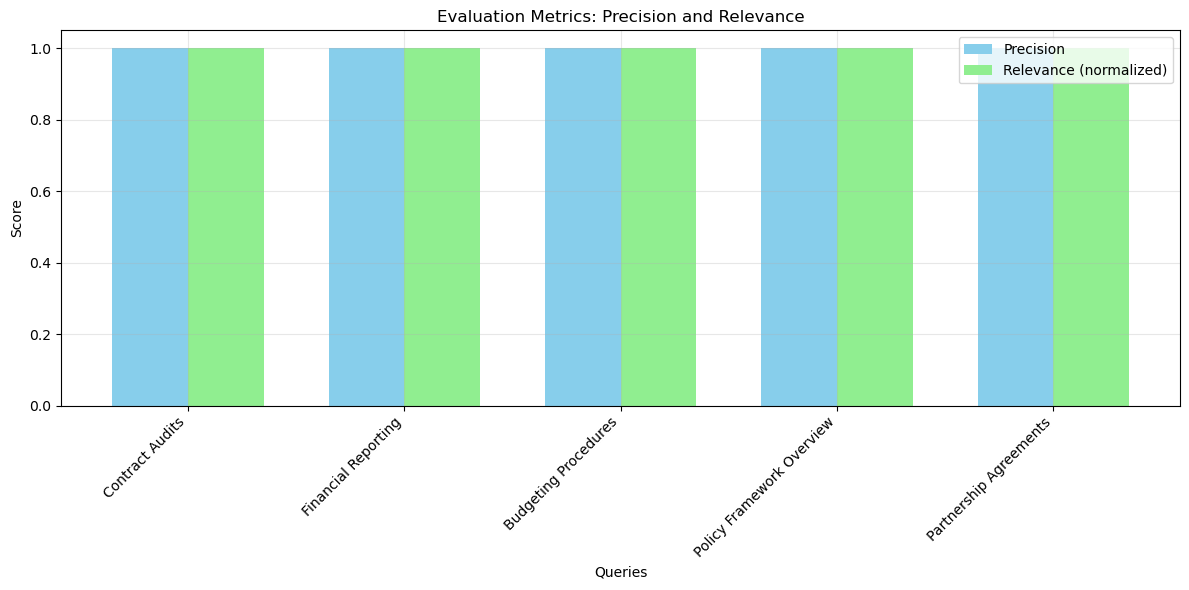

C:\Users\Bright\AppData\Local\Temp\ipykernel_22020\210496152.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(queries, rotation=45, ha='right')


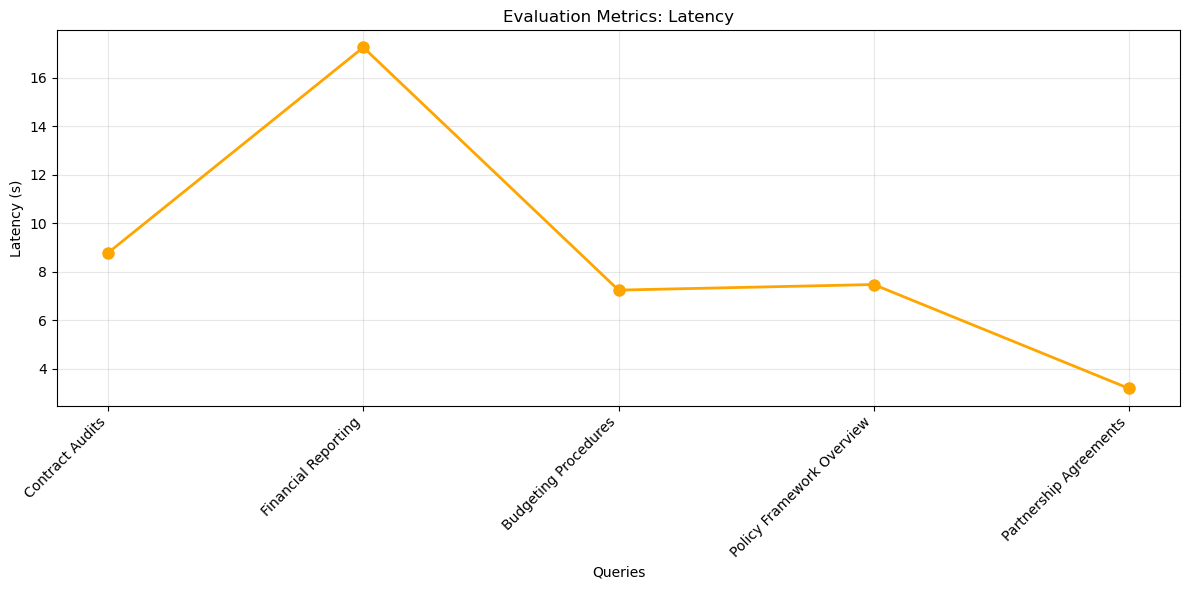

Visualizations saved as 'metrics_bar_chart.png' and 'latency_line_plot.png'


In [1]:
# Cell 19: Generate Metrics Visualizations
import matplotlib.pyplot as plt
import numpy as np

# Data from the evaluation summary
queries = [
    'Contract Audits',
    'Financial Reporting',
    'Budgeting Procedures',
    'Policy Framework Overview',
    'Partnership Agreements'
]

precision = [1.00, 1.00, 1.00, 1.00, 1.00]
relevance = [5, 5, 5, 5, 5]
latency = [8.78, 17.26, 7.24, 7.47, 3.18]

# Bar chart for precision and relevance (normalized to 0-1)
x = np.arange(len(queries))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width/2, precision, width, label='Precision', color='skyblue')
ax.bar(x + width/2, [r/5 for r in relevance], width, label='Relevance (normalized)', color='lightgreen')

ax.set_xlabel('Queries')
ax.set_ylabel('Score')
ax.set_title('Evaluation Metrics: Precision and Relevance')
ax.set_xticks(x)
ax.set_xticklabels(queries, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('metrics_bar_chart.png', dpi=300, bbox_inches='tight')
plt.show()

# Line plot for latency
fig2, ax2 = plt.subplots(figsize=(12, 6))
ax2.plot(queries, latency, marker='o', color='orange', linestyle='-', linewidth=2, markersize=8)
ax2.set_xlabel('Queries')
ax2.set_ylabel('Latency (s)')
ax2.set_title('Evaluation Metrics: Latency')
ax2.set_xticklabels(queries, rotation=45, ha='right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('latency_line_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualizations saved as 'metrics_bar_chart.png' and 'latency_line_plot.png'")

### Running Full Dataset

In [8]:
# Cell 20: Update Data Processing and Vector Store for Full Dataset (Fixed with Batching)
import pandas as pd
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings
import logging
from datetime import datetime
import os

# Set up logging for errors
logging.basicConfig(filename="rag_errors.log", level=logging.WARNING,
                    format="%(asctime)s - %(levelname)s - %(message)s")

# Initialize embeddings
embeddings_model = OpenAIEmbeddings(model="text-embedding-ada-002")

# Load metadata
try:
    metadata_df = pd.read_csv("document_metadata.csv")
    print(f"Loaded {len(metadata_df)} PDFs from document_metadata.csv")
except Exception as e:
    logging.error(f"Failed to load document_metadata.csv: {e}")
    print(f"Failed to load document_metadata.csv: {e}")
    raise

# Process PDFs
documents = []
for _, row in metadata_df.iterrows():
    pdf_path = row['file_path']
    category = row['category']
    series = row['series']

    try:
        loader = PyPDFLoader(pdf_path)
        pages = loader.load()
        # Extract creationdate from the first page's metadata (if available)
        creationdate = pages[0].metadata.get('creationdate', None)

        # Convert creationdate to Unix timestamp
        creation_timestamp = 0
        if creationdate:
            try:
                creation_timestamp = int(datetime.strptime(creationdate, '%Y-%m-%dT%H:%M:%S%z').timestamp())
            except Exception as e:
                logging.warning(f"Failed to parse creationdate for {pdf_path}: {e}")

        for page in pages:
            page.metadata.update({
                'category': category,
                'series': series,
                'creationdate': creationdate,
                'creation_timestamp': creation_timestamp
            })
        documents.extend(pages)
    except Exception as e:
        logging.warning(f"Failed to load PDF {pdf_path}: {e}")
        print(f"Warning: Failed to load PDF {pdf_path}: {e}")

# Chunk documents
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200,
    length_function=len
)
chunks = text_splitter.split_documents(documents)
print(f"Created {len(chunks)} chunks from {len(documents)} pages")

# Create and populate vector store in batches
PERSISTENT_DIR = "./chroma_db_full"
BATCH_SIZE = 5000  # Stay below ChromaDB's max batch size of 5461
try:
    vectorstore = Chroma(
        collection_name="nasa_policies",
        embedding_function=embeddings_model,
        persist_directory=PERSISTENT_DIR
    )
    # Split chunks into batches
    for i in range(0, len(chunks), BATCH_SIZE):
        batch = chunks[i:i + BATCH_SIZE]
        vectorstore.add_documents(batch)
        print(f"Added batch {i // BATCH_SIZE + 1} of {len(batch)} chunks")
    print(f"Populated vector store with {vectorstore._collection.count()} chunks in {PERSISTENT_DIR}")
except Exception as e:
    logging.error(f"Failed to populate vector store: {e}")
    print(f"Failed to populate vector store: {e}")
    raise

Loaded 212 PDFs from document_metadata.csv
Created 14552 chunks from 4285 pages
Added batch 1 of 5000 chunks
Added batch 2 of 5000 chunks
Added batch 3 of 4552 chunks
Populated vector store with 14552 chunks in ./chroma_db_full


In [9]:
!pip install streamlit

In [ ]:
!streamlit run app.py